# To Plot The Histogram of Interference Strengths for Different Test Set

## For Failure Prediction Test Set B

In [12]:
import pandas as pd
import numpy as np

NUM_UAV = 8

DATASETS = ["/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_uav_interference/uav_scenario_0_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_uav_interference/uav_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_uav_interference/uav_scenario_2_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_manet_interference/manet_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_manet_interference/manet_scenario_a_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_manet_interference/manet_scenario_2_{}_processed.csv"]
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Failure_Prediction_Test_Set_Mean_Interference_Strength_All_Runs.csv"

'''For convergence (L=100)'''
# For runs within a range
START_RUN_NUM = 300
END_RUN_NUM = 399
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Failure_Prediction_Test_Set_Mean_Interference_Strength_{}-{}_Runs.csv".format(START_RUN_NUM, END_RUN_NUM)

int_strength_list = [] # To store the interference strengths from each run in the group
for j in range(len(DATASETS)):
    '''Load Dataset'''
    dataset = DATASETS[j]
    scenario = dataset.split("/")[-1]
    ul_num_reliable_df = pd.read_csv(dataset.format("ul"))
    ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
    dl_num_reliable_df_list = []
    for i in range(NUM_UAV):
        df = pd.read_csv(dataset.format("UAV_" + str(i)))
        df = df.loc[df["Time"] >= 1]
        dl_num_reliable_df_list.append(df)

    '''Get the different combinations of USI, Bit_Rate, Speed, and Height using groupby'''
    gcs_groups = ul_num_reliable_df.groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav0_groups = dl_num_reliable_df_list[0].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav1_groups = dl_num_reliable_df_list[1].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav2_groups = dl_num_reliable_df_list[2].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav3_groups = dl_num_reliable_df_list[3].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav4_groups = dl_num_reliable_df_list[4].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav5_groups = dl_num_reliable_df_list[5].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav6_groups = dl_num_reliable_df_list[6].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav7_groups = dl_num_reliable_df_list[7].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    
    # Check that the same combination is in each group (Optional, shouldn't need to)
    # assert set(gcs_group.groups.keys()) == set(uav0_group.groups.keys()) == set(uav1_group.groups.keys()) == set(uav2_group.groups.keys()) == set(uav3_group.groups.keys()) \
    # == set(uav4_group.groups.keys()) == set(uav5_group.groups.keys()) == set(uav6_group.groups.keys()) == set(uav7_group.groups.keys()), "Combinations not the same in all groups"

    '''Get the mean Measured_Reliability_1 over all windows and links for each group (combinations)'''
    for group in set(gcs_groups.groups.keys()):
        gcs_group = gcs_groups.get_group(group)
        uav0_group = uav0_groups.get_group(group)
        uav1_group = uav1_groups.get_group(group)
        uav2_group = uav2_groups.get_group(group)
        uav3_group = uav3_groups.get_group(group)
        uav4_group = uav4_groups.get_group(group)
        uav5_group = uav5_groups.get_group(group)
        uav6_group = uav6_groups.get_group(group)
        uav7_group = uav7_groups.get_group(group)

        '''Group by Run_Num and get averages over all time windows and links'''
        gcs_run_groups = gcs_group.groupby(["Run_Num"])
        uav0_run_groups = uav0_group.groupby(["Run_Num"])
        uav1_run_groups = uav1_group.groupby(["Run_Num"])
        uav2_run_groups = uav2_group.groupby(["Run_Num"])
        uav3_run_groups = uav3_group.groupby(["Run_Num"])
        uav4_run_groups = uav4_group.groupby(["Run_Num"])
        uav5_run_groups = uav5_group.groupby(["Run_Num"])
        uav6_run_groups = uav6_group.groupby(["Run_Num"])
        uav7_run_groups = uav7_group.groupby(["Run_Num"])

        for run_group in set(gcs_run_groups.groups.keys()):
            if (int(run_group) >= START_RUN_NUM) & (int(run_group) <= END_RUN_NUM):
                gcs_run_df = gcs_run_groups.get_group(run_group)
                uav0_run_df = uav0_run_groups.get_group(run_group)
                uav1_run_df = uav1_run_groups.get_group(run_group)
                uav2_run_df = uav2_run_groups.get_group(run_group)
                uav3_run_df = uav3_run_groups.get_group(run_group)
                uav4_run_df = uav4_run_groups.get_group(run_group)
                uav5_run_df = uav5_run_groups.get_group(run_group)
                uav6_run_df = uav6_run_groups.get_group(run_group)
                uav7_run_df = uav7_run_groups.get_group(run_group)

                # Check that the length of each run_df is the same
                assert len(gcs_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) \
                    == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df), "Run group length not the same: Combination - {}, Run - {}".format(group, run_group)
                
                interference_strength = np.mean([gcs_run_df["Measured_Reliability_1"].mean(), uav0_run_df["Measured_Reliability_1"].mean(), uav1_run_df["Measured_Reliability_1"].mean(), 
                                                uav2_run_df["Measured_Reliability_1"].mean(), uav3_run_df["Measured_Reliability_1"].mean(), uav4_run_df["Measured_Reliability_1"].mean(), 
                                                uav5_run_df["Measured_Reliability_1"].mean(), uav6_run_df["Measured_Reliability_1"].mean(), uav7_run_df["Measured_Reliability_1"].mean()])
                int_strength_list.append({"Scenario": scenario, "Combination": group, "Run_Mean_Interference_Strength": interference_strength})

    mean_int_strength_df = pd.DataFrame(int_strength_list)
    mean_int_strength_df.to_csv(SAVEPATH)


In [1]:
import pandas as pd
import numpy as np

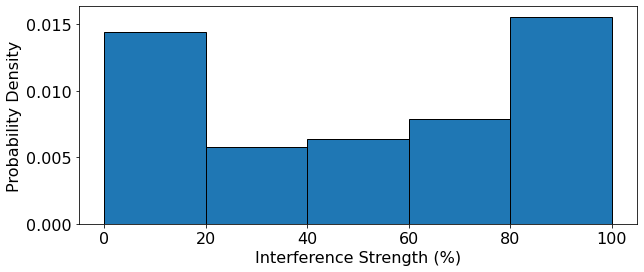

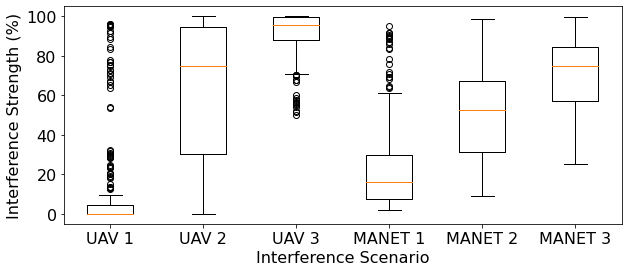

In [3]:
'''Plot the histogram of interference strengths'''
import matplotlib.pyplot as plt

FILE = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Failure_Prediction_Test_Set_Mean_Interference_Strength_300-399_Runs.csv"
df = pd.read_csv(FILE)
# Get mean over runs for each combination 
mean_int_strength_list = []
uav_0_int_str = []
uav_1_int_str = []
uav_2_int_str = []
manet_1_int_str = []
manet_a_int_str = []
manet_2_int_str = []
groups = df.groupby(["Scenario", "Combination"])
for group in set(groups.groups.keys()):
    scenario = group[0]
    group_df = groups.get_group(group)
    mean_int_str = (1 - group_df["Run_Mean_Interference_Strength"].mean(skipna=True)) * 100
    mean_int_strength_list.append(mean_int_str)
    if scenario == "uav_scenario_0_{}_processed.csv":
        uav_0_int_str.append(mean_int_str)
    elif scenario == "uav_scenario_1_{}_processed.csv":
        uav_1_int_str.append(mean_int_str)
    elif scenario == "uav_scenario_2_{}_processed.csv":
        uav_2_int_str.append(mean_int_str)
    elif scenario == "manet_scenario_1_{}_processed.csv":
        manet_1_int_str.append(mean_int_str)
    elif scenario == "manet_scenario_a_{}_processed.csv":
        manet_a_int_str.append(mean_int_str)
    elif scenario == "manet_scenario_2_{}_processed.csv":
        manet_2_int_str.append(mean_int_str)

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(mean_int_strength_list, bins=[0, 20, 40, 60, 80, 100], density=True, edgecolor='k')
ax.set_xlabel("Interference Strength (%)")
ax.set_ylabel("Probability Density")

plt.rcParams.update({'font.size': 16})
fig1, ax1 = plt.subplots(figsize=(10,4))
box = ax1.boxplot([uav_0_int_str, uav_1_int_str, uav_2_int_str, manet_1_int_str, manet_a_int_str, manet_2_int_str], showmeans=False)
ax1.set_ylabel("Interference Strength (%)")
ax1.set_xlabel("Interference Scenario")
ax1.set_xticks(np.arange(1, 7), ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"])

## For No-Mitigation Test Set

In [ ]:
import pandas as pd
import numpy as np

NUM_UAV = 8

DATASETS = ["/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new/uav_scenario_0_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new/uav_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new/uav_scenario_2_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new/manet_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new/manet_scenario_a_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new/manet_scenario_2_{}_processed.csv"]
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/No_Mitigation_Test_Set_Mean_Interference_Strength_All_Runs.csv"

'''For convergence (L=100)'''
# For runs within a range
START_RUN_NUM = 300
END_RUN_NUM = 399
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/No_Mitigation_Test_Set_Mean_Interference_Strength_{}-{}_Runs.csv".format(START_RUN_NUM, END_RUN_NUM)

int_strength_list = [] # To store the interference strengths from each run in the group
for j in range(len(DATASETS)):
    '''Load Dataset'''
    dataset = DATASETS[j]
    scenario = dataset.split("/")[-1]
    ul_num_reliable_df = pd.read_csv(dataset.format("ul"))
    ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
    dl_num_reliable_df_list = []
    for i in range(NUM_UAV):
        df = pd.read_csv(dataset.format("UAV_" + str(i)))
        df = df.loc[df["Time"] >= 1]
        dl_num_reliable_df_list.append(df)

    '''Get the different combinations of USI, Bit_Rate, Speed, and Height using groupby'''
    gcs_groups = ul_num_reliable_df.groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav0_groups = dl_num_reliable_df_list[0].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav1_groups = dl_num_reliable_df_list[1].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav2_groups = dl_num_reliable_df_list[2].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav3_groups = dl_num_reliable_df_list[3].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav4_groups = dl_num_reliable_df_list[4].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav5_groups = dl_num_reliable_df_list[5].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav6_groups = dl_num_reliable_df_list[6].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav7_groups = dl_num_reliable_df_list[7].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    
    # Check that the same combination is in each group (Optional, shouldn't need to)
    # assert set(gcs_group.groups.keys()) == set(uav0_group.groups.keys()) == set(uav1_group.groups.keys()) == set(uav2_group.groups.keys()) == set(uav3_group.groups.keys()) \
    # == set(uav4_group.groups.keys()) == set(uav5_group.groups.keys()) == set(uav6_group.groups.keys()) == set(uav7_group.groups.keys()), "Combinations not the same in all groups"

    '''Get the mean Measured_Reliability_1 over all runs for each group (combinations)'''
    for group in set(gcs_groups.groups.keys()):
        gcs_group = gcs_groups.get_group(group)
        uav0_group = uav0_groups.get_group(group)
        uav1_group = uav1_groups.get_group(group)
        uav2_group = uav2_groups.get_group(group)
        uav3_group = uav3_groups.get_group(group)
        uav4_group = uav4_groups.get_group(group)
        uav5_group = uav5_groups.get_group(group)
        uav6_group = uav6_groups.get_group(group)
        uav7_group = uav7_groups.get_group(group)

        '''Group by Run_Num and get averages over all time windows and links'''
        gcs_run_groups = gcs_group.groupby(["Run_Num"])
        uav0_run_groups = uav0_group.groupby(["Run_Num"])
        uav1_run_groups = uav1_group.groupby(["Run_Num"])
        uav2_run_groups = uav2_group.groupby(["Run_Num"])
        uav3_run_groups = uav3_group.groupby(["Run_Num"])
        uav4_run_groups = uav4_group.groupby(["Run_Num"])
        uav5_run_groups = uav5_group.groupby(["Run_Num"])
        uav6_run_groups = uav6_group.groupby(["Run_Num"])
        uav7_run_groups = uav7_group.groupby(["Run_Num"])

        for run_group in set(gcs_run_groups.groups.keys()):
            if (int(run_group) >= START_RUN_NUM) & (int(run_group) <= END_RUN_NUM):
                gcs_run_df = gcs_run_groups.get_group(run_group)
                uav0_run_df = uav0_run_groups.get_group(run_group)
                uav1_run_df = uav1_run_groups.get_group(run_group)
                uav2_run_df = uav2_run_groups.get_group(run_group)
                uav3_run_df = uav3_run_groups.get_group(run_group)
                uav4_run_df = uav4_run_groups.get_group(run_group)
                uav5_run_df = uav5_run_groups.get_group(run_group)
                uav6_run_df = uav6_run_groups.get_group(run_group)
                uav7_run_df = uav7_run_groups.get_group(run_group)

                # Check that the length of each run_df is the same
                assert len(gcs_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) \
                    == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df), "Run group length not the same: Combination - {}, Run - {}".format(group, run_group)
                
                interference_strength = np.mean([gcs_run_df["Measured_Reliability_1"].mean(), uav0_run_df["Measured_Reliability_1"].mean(), uav1_run_df["Measured_Reliability_1"].mean(), 
                                                uav2_run_df["Measured_Reliability_1"].mean(), uav3_run_df["Measured_Reliability_1"].mean(), uav4_run_df["Measured_Reliability_1"].mean(), 
                                                uav5_run_df["Measured_Reliability_1"].mean(), uav6_run_df["Measured_Reliability_1"].mean(), uav7_run_df["Measured_Reliability_1"].mean()])
                int_strength_list.append({"Scenario": scenario, "Combination": group, "Run_Mean_Interference_Strength": interference_strength})
    

    mean_int_strength_df = pd.DataFrame(int_strength_list)
    mean_int_strength_df.to_csv(SAVEPATH)


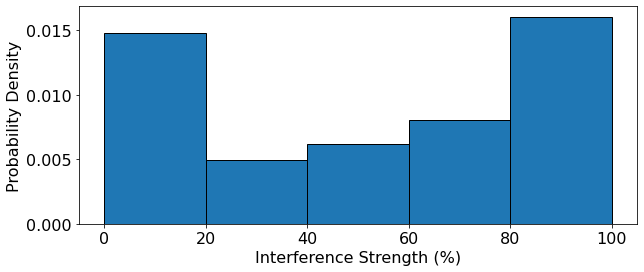

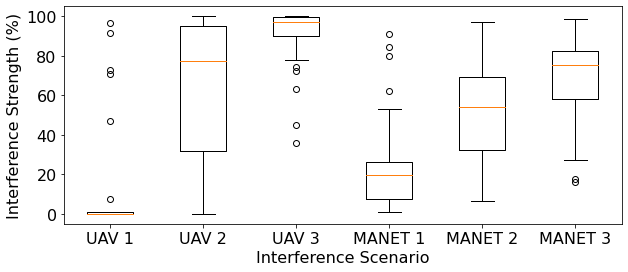

In [4]:
'''Plot the histogram of interference strengths'''
import matplotlib.pyplot as plt

FILE = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/No_Mitigation_Test_Set_Mean_Interference_Strength_300-399_Runs.csv"
df = pd.read_csv(FILE)

# Get mean over runs for each combination
mean_int_strength_list = []
uav_0_int_str = []
uav_1_int_str = []
uav_2_int_str = []
manet_1_int_str = []
manet_a_int_str = []
manet_2_int_str = []
groups = df.groupby(["Scenario", "Combination"])
for group in set(groups.groups.keys()):
    scenario = group[0]
    group_df = groups.get_group(group)
    mean_int_str = (1 - group_df["Run_Mean_Interference_Strength"].mean(skipna=True)) * 100
    mean_int_strength_list.append(mean_int_str)
    if scenario == "uav_scenario_0_{}_processed.csv":
        uav_0_int_str.append(mean_int_str)
    elif scenario == "uav_scenario_1_{}_processed.csv":
        uav_1_int_str.append(mean_int_str)
    elif scenario == "uav_scenario_2_{}_processed.csv":
        uav_2_int_str.append(mean_int_str)
    elif scenario == "manet_scenario_1_{}_processed.csv":
        manet_1_int_str.append(mean_int_str)
    elif scenario == "manet_scenario_a_{}_processed.csv":
        manet_a_int_str.append(mean_int_str)
    elif scenario == "manet_scenario_2_{}_processed.csv":
        manet_2_int_str.append(mean_int_str)

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(mean_int_strength_list, bins=[0, 20, 40, 60, 80, 100], density=True, edgecolor='k')
ax.set_xlabel("Interference Strength (%)")
ax.set_ylabel("Probability Density")

plt.rcParams.update({'font.size': 16})
fig1, ax1 = plt.subplots(figsize=(10,4))
box = ax1.boxplot([uav_0_int_str, uav_1_int_str, uav_2_int_str, manet_1_int_str, manet_a_int_str, manet_2_int_str], showmeans=False)
ax1.set_ylabel("Interference Strength (%)")
ax1.set_xlabel("Interference Scenario")
ax1.set_xticks(np.arange(1, 7), ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"])

## For Mitigation Test Set Before Switch

In [10]:
import pandas as pd
import numpy as np

NUM_UAV = 8

DATASETS = ["/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new/uav_scenario_0_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new/uav_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new/uav_scenario_2_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new/manet_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new/manet_scenario_a_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new/manet_scenario_2_{}_processed.csv"]
SWITCH_TIME_FILES = ["/home/research-student/reuben_ws/omnet-fanet/obj3_scenario_script_new/uav_scenario_0/Switch_Details.csv",
                     "/home/research-student/reuben_ws/omnet-fanet/obj3_scenario_script_new/uav_scenario_1/Switch_Details.csv",
                     "/home/research-student/reuben_ws/omnet-fanet/obj3_scenario_script_new/uav_scenario_2/Switch_Details.csv",
                     "/home/research-student/reuben_ws/omnet-fanet/obj3_scenario_script_new/manet_scenario_1/Switch_Details.csv",
                     "/home/research-student/reuben_ws/omnet-fanet/obj3_scenario_script_new/manet_scenario_a/Switch_Details.csv",
                     "/home/research-student/reuben_ws/omnet-fanet/obj3_scenario_script_new/manet_scenario_2/Switch_Details.csv"]
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mitigation_Test_Set_Before_Switch_Mean_Interference_Strength_All_Runs.csv"
# SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mitigation_Test_Set_Before_Switch_After1s_Mean_Interference_Strength_All_Runs.csv"
SCENARIOS = ["uav_scenario_0", "uav_scenario_1", "uav_scenario_2", "manet_scenario_1", "manet_scenario_a", "manet_scenario_2"]

'''For convergence (L=100)'''
# For runs within a range
START_RUN_NUM = 300
END_RUN_NUM = 399
SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mitigation_Test_Set_Before_Switch_Mean_Interference_Strength_{}-{}_Runs.csv".format(START_RUN_NUM, END_RUN_NUM)
# SAVEPATH = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mitigation_Test_Set_Before_Switch_After1s_Mean_Interference_Strength_{}-{}_Runs.csv".format(START_RUN_NUM, END_RUN_NUM)

int_strength_list = [] # To store the interference strengths from each run in the group
for j in range(len(DATASETS)):
    switch_df = pd.read_csv(SWITCH_TIME_FILES[j])

    '''Load Dataset'''
    dataset = DATASETS[j]
    scenario = dataset.split("/")[-1]
    ul_num_reliable_df = pd.read_csv(dataset.format("ul"))
    ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
    dl_num_reliable_df_list = []
    for i in range(NUM_UAV):
        df = pd.read_csv(dataset.format("UAV_" + str(i)))
        df = df.loc[df["Time"] >= 1]
        dl_num_reliable_df_list.append(df)

    '''Get the different combinations of USI, Bit_Rate, Speed, and Height using groupby'''
    gcs_groups = ul_num_reliable_df.groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav0_groups = dl_num_reliable_df_list[0].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav1_groups = dl_num_reliable_df_list[1].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav2_groups = dl_num_reliable_df_list[2].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav3_groups = dl_num_reliable_df_list[3].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav4_groups = dl_num_reliable_df_list[4].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav5_groups = dl_num_reliable_df_list[5].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav6_groups = dl_num_reliable_df_list[6].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    uav7_groups = dl_num_reliable_df_list[7].groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    switch_groups = switch_df.groupby(['USI', 'Bit_Rate', 'Height', 'UAV_Speed'])
    # Check that the same combination is in each group (Optional, shouldn't need to)
    # assert set(gcs_group.groups.keys()) == set(uav0_group.groups.keys()) == set(uav1_group.groups.keys()) == set(uav2_group.groups.keys()) == set(uav3_group.groups.keys()) \
    # == set(uav4_group.groups.keys()) == set(uav5_group.groups.keys()) == set(uav6_group.groups.keys()) == set(uav7_group.groups.keys()), "Combinations not the same in all groups"

    '''Get the mean Measured_Reliability_1 over all windows and links for each group (combinations)'''
    for group in set(gcs_groups.groups.keys()):
        gcs_group = gcs_groups.get_group(group)
        uav0_group = uav0_groups.get_group(group)
        uav1_group = uav1_groups.get_group(group)
        uav2_group = uav2_groups.get_group(group)
        uav3_group = uav3_groups.get_group(group)
        uav4_group = uav4_groups.get_group(group)
        uav5_group = uav5_groups.get_group(group)
        uav6_group = uav6_groups.get_group(group)
        uav7_group = uav7_groups.get_group(group)
        switch_group = switch_groups.get_group(group)

        '''Group by Run_Num and get averages over all time windows and links'''
        gcs_run_groups = gcs_group.groupby(["Run_Num"])
        uav0_run_groups = uav0_group.groupby(["Run_Num"])
        uav1_run_groups = uav1_group.groupby(["Run_Num"])
        uav2_run_groups = uav2_group.groupby(["Run_Num"])
        uav3_run_groups = uav3_group.groupby(["Run_Num"])
        uav4_run_groups = uav4_group.groupby(["Run_Num"])
        uav5_run_groups = uav5_group.groupby(["Run_Num"])
        uav6_run_groups = uav6_group.groupby(["Run_Num"])
        uav7_run_groups = uav7_group.groupby(["Run_Num"])

        
        for run_group in set(gcs_run_groups.groups.keys()):
            if (int(run_group) >= START_RUN_NUM) & (int(run_group) <= END_RUN_NUM):
                gcs_run_df = gcs_run_groups.get_group(run_group)
                uav0_run_df = uav0_run_groups.get_group(run_group)
                uav1_run_df = uav1_run_groups.get_group(run_group)
                uav2_run_df = uav2_run_groups.get_group(run_group)
                uav3_run_df = uav3_run_groups.get_group(run_group)
                uav4_run_df = uav4_run_groups.get_group(run_group)
                uav5_run_df = uav5_run_groups.get_group(run_group)
                uav6_run_df = uav6_run_groups.get_group(run_group)
                uav7_run_df = uav7_run_groups.get_group(run_group)
                
                # Check that the length of each run_df is the same
                assert len(gcs_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df) \
                    == len(uav0_run_df) == len(uav0_run_df) == len(uav0_run_df), "Run group length not the same: Combination - {}, Run - {}".format(group, run_group)
                
                switch_run_df = switch_group.loc[switch_group["Run"]==run_group]
                switch_time = switch_run_df[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
                                            "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]].min(axis=1).values[0]
                
                # To exclude runs without switching (switch time is nan or <1)
                if (np.isnan(switch_time)) or (switch_time<1):
                    continue
                # # UNCOMMENT BELOW TO INSTEAD exclude runs without switching or switched at 1 s
                # if (np.isnan(switch_time)) or (switch_time<=1):
                #     continue

                gcs_run_df = gcs_run_df.loc[gcs_run_df["Time"]<=switch_time]
                uav0_run_df = uav0_run_df.loc[uav0_run_df["Time"]<=switch_time]
                uav1_run_df = uav1_run_df.loc[uav1_run_df["Time"]<=switch_time]
                uav2_run_df = uav2_run_df.loc[uav2_run_df["Time"]<=switch_time]
                uav3_run_df = uav3_run_df.loc[uav3_run_df["Time"]<=switch_time]
                uav4_run_df = uav4_run_df.loc[uav4_run_df["Time"]<=switch_time]
                uav5_run_df = uav5_run_df.loc[uav5_run_df["Time"]<=switch_time]
                uav6_run_df = uav6_run_df.loc[uav6_run_df["Time"]<=switch_time]
                uav7_run_df = uav7_run_df.loc[uav7_run_df["Time"]<=switch_time]
                
                if len(gcs_run_df) == 0:
                    continue

                interference_strength = np.nanmean([gcs_run_df["Measured_Reliability_1"].mean(), uav0_run_df["Measured_Reliability_1"].mean(), uav1_run_df["Measured_Reliability_1"].mean(), 
                                                uav2_run_df["Measured_Reliability_1"].mean(), uav3_run_df["Measured_Reliability_1"].mean(), uav4_run_df["Measured_Reliability_1"].mean(), 
                                                uav5_run_df["Measured_Reliability_1"].mean(), uav6_run_df["Measured_Reliability_1"].mean(), uav7_run_df["Measured_Reliability_1"].mean()])
                int_strength_list.append({"Scenario": scenario, "Combination": group, "Run_Mean_Interference_Strength": interference_strength})

    mean_int_strength_df = pd.DataFrame(int_strength_list)
    mean_int_strength_df.to_csv(SAVEPATH)

Text(0, 0.5, 'Probability Density')

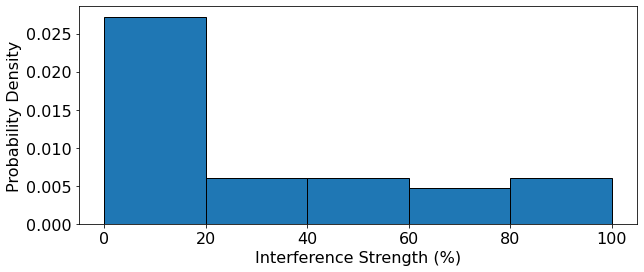

In [5]:
'''Plot the histogram of interference strengths'''
import matplotlib.pyplot as plt

FILE = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mitigation_Test_Set_Before_Switch_Mean_Interference_Strength_300-399_Runs.csv"
# FILE = "/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Mitigation_Test_Set_Before_Switch_After1s_Mean_Interference_Strength_All_Runs.csv"

# Get mean over runs for each combination
mean_int_strength_list = []
df = pd.read_csv(FILE)
groups = df.groupby(["Scenario", "Combination"])
for group in set(groups.groups.keys()):
    group_df = groups.get_group(group)
    mean_int_strength_list.append(group_df["Run_Mean_Interference_Strength"].mean(skipna=True))

mean_int_strength = (1 - np.array(mean_int_strength_list))*100

# int_strength_ratings = np.digitize(mean_int_strength, bins=[20, 40, 60, 80, 100])

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(mean_int_strength, bins=[0, 20, 40, 60, 80, 100], density=True, edgecolor='k')
ax.set_xlabel("Interference Strength (%)")
ax.set_ylabel("Probability Density")